# Analysis: gesture, speech, and sway coupling

This notebook loads the artefacts written by `preprocessing.ipynb` (in
`./intermediateoutput/`) and measures coupling between speech-envelope power and
body sway. Run the preprocessing notebook first. Nothing here re-does the
conditioning: the aligned series, surrogates, voicing, and gestures are read
from disk.

In [47]:
import os, glob
import numpy as np
import pandas as pd
import emd
from scipy.signal import hilbert
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# everything preprocessing produced lives here
OUT_DIR = './intermediateoutput'

# these must match the values used in preprocessing.ipynb (kept in sync by hand)
FS           = 500.0
EDGE_SECONDS = 1.0

# the preprocessed files themselves are the trial list
aligned_files = sorted(glob.glob(os.path.join(OUT_DIR, 'aligned_*.csv')))
voicing = pd.read_csv(os.path.join(OUT_DIR, 'voicing.csv'))   # voiced onset/offset per trial
gest    = pd.read_csv(os.path.join(OUT_DIR, 'gestures.csv'))  # cue-giver gestures: onset/offset plus kinematics
meta_all = pd.read_csv('../../metadata.csv')                  # trial conditions, from the raw metadata (as before)

# for convenience, parse the trial name to get all info to connect to other files (e.g., meta, or aligned)
def parse_aligned_filename(path):
    """aligned_103_203_12.csv gives ('103_203', 12)."""
    parts = os.path.splitext(os.path.basename(path))[0].split('_')
    return f"{parts[1]}_{parts[2]}", int(parts[3])

print(f"{len(aligned_files)} aligned trials, {len(gest)} gestures, {len(voicing)} voiced segments")

80 aligned trials, 604 gestures, 2317 voiced segments


## Empirical Mode Decomposition

The envelope for one trial, its two IMFs and their power, with the voiced and gesture windows shaded and the sway lean overlaid. The envelope and IMFs are the full trial.

6 gestures, 26 voiced segments (trial ends 17.3s)


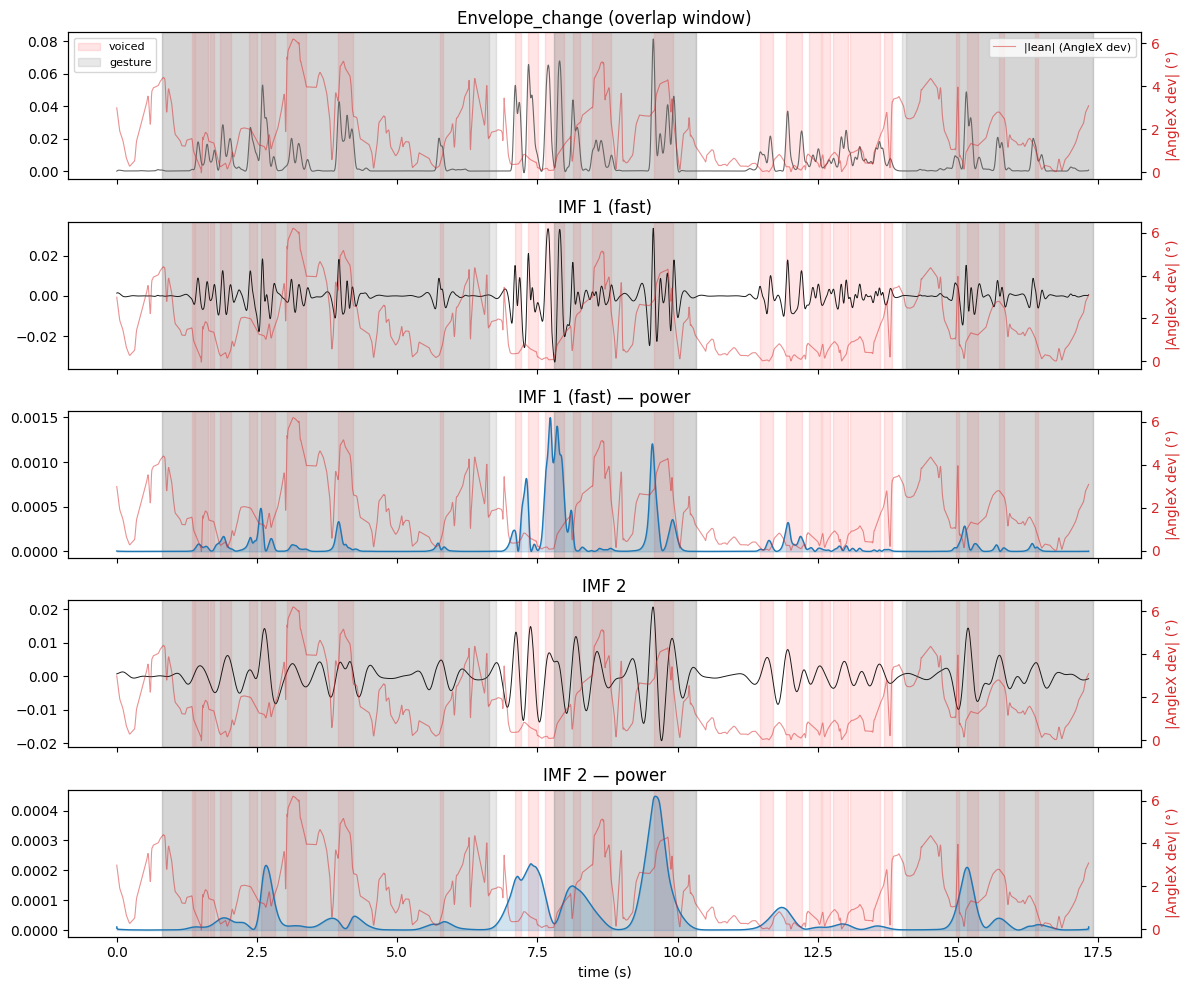

In [48]:
# inspect one trial (loaded from the preprocessing artefacts)
EXAMPLE = 0
example_path = aligned_files[EXAMPLE]
pair, trail_number = parse_aligned_filename(example_path)
aligned = pd.read_csv(example_path)   # time, envelope, sway_speed, sway_lean, condition
time      = aligned['time'].to_numpy()
sig       = aligned['envelope_change'].to_numpy()
sway_lean = aligned['sway_lean'].to_numpy()

# decompose the envelope and take each IMF's power (this is the method)
imf_env = emd.sift.mask_sift(sig, max_imfs=2)
amp = np.abs(hilbert(imf_env, axis=0))
pwr = amp ** 2

# gesture and voiced windows for THIS trial (onset/offset already in the tables)
spans  = gest[(gest['pair'] == pair) & (gest['trial'] == trail_number)][['onset', 'offset']]
vspans = voicing[(voicing['pair'] == pair) & (voicing['trial'] == trail_number)]
print(f"{len(spans)} gestures, {len(vspans)} voiced segments (trial ends {time[-1]:.1f}s)")

def overlay_lean(a, show_label=False):
    ab = a.twinx()
    ab.plot(time, sway_lean, color='C3', lw=0.8, alpha=0.5, label='|lean| (AngleX dev)')
    ab.set_ylabel('|AngleX dev| (°)', color='C3'); ab.tick_params(axis='y', labelcolor='C3')
    if show_label:
        ab.legend(loc='upper right', fontsize=8)
    return ab

def mark_gestures(a, label=False):
    for i, (onset, offset) in enumerate(spans.itertuples(index=False)):
        a.axvspan(onset, offset, color='0.5', alpha=0.18, zorder=0,
                  label='gesture' if (label and i == 0) else None)

def mark_voiced(a, label=False):
    for i, (on, off) in enumerate(vspans[['onset','offset']].itertuples(index=False)):
        a.axvspan(on, off, color='red', alpha=0.10, zorder=0,
                  label='voiced' if (label and i == 0) else None)

fig, ax = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

ax[0].plot(time, sig, color='0.4', lw=0.8)
ax[0].set_title('Envelope_change (overlap window)')
mark_voiced(ax[0], label=True); mark_gestures(ax[0], label=True); overlay_lean(ax[0], show_label=True)
ax[0].legend(loc='upper left', fontsize=8)

for k, name in [(0, 'IMF 1 (fast)'), (1, 'IMF 2')]:
    a_imf = ax[1 + 2 * k] # axis for this IMF
    a_imf.plot(time, imf_env[:, k], color='0.1', lw=0.7)
    a_imf.set_title(name)
    mark_voiced(a_imf); mark_gestures(a_imf); overlay_lean(a_imf)

    a_pwr = ax[2 + 2 * k] # axis for this IMF's power
    a_pwr.plot(time, pwr[:, k], 'C0', lw=1.0)
    a_pwr.fill_between(time, pwr[:, k], color='C0', alpha=0.2)
    a_pwr.set_title(f'{name} — power')
    mark_voiced(a_pwr); mark_gestures(a_pwr); overlay_lean(a_pwr)

ax[-1].set_xlabel('time (s)')
plt.tight_layout()

## Coupling across all trials, with the surrogate test

For each trial we decompose the envelope with EMD, take the power of each IMF, and correlate it with the sway lean on the edge-trimmed part of the trial. We do this for the whole trial and for voiced, unvoiced, gesture, and still frames, and compare each observed correlation against that trial's surrogate baseline.

Note we are looking at the correlation between the envelope change IMF1 and IMF2 power and the sway lean.

We will look at the voiced portions only, and gesture versus non-gesture (still) portions.

In [49]:
import os, glob
import numpy as np, pandas as pd, emd
from scipy.signal import hilbert
from scipy.stats import spearmanr

def masked_rho(x_full, lean_full, surr, mask):
    """Observed Spearman rho on the masked frames, with a p-value and mean from the surrogates."""
    if mask.sum() < 20:
        return np.nan, np.nan, np.nan
    rho, _ = spearmanr(x_full[mask], lean_full[mask])
    null = np.array([spearmanr(x_full[mask], s[mask])[0] for s in surr])   # same mask on each surrogate
    p = (np.sum(np.abs(null) >= abs(rho)) + 1) / (len(surr) + 1)
    return rho, p, null.mean()

def _mask_from_spans(spans, time):
    """Boolean mask over time, True inside any (onset, offset) span."""
    m = np.zeros(len(time), dtype=bool)
    for on, off in spans[['onset', 'offset']].itertuples(index=False):
        m |= (time >= on) & (time <= off)
    return m

def analyse_trial(aligned_path):
    pair, trial = parse_aligned_filename(aligned_path)

    # condition comes from the raw metadata (as before)
    meta = meta_all[(meta_all['pair_id'] == pair) & (meta_all['trial_number'] == trial)]
    condition = meta['clue_giver_condition'].iloc[0] if len(meta) else np.nan
    
    # so we can only analyse the trial with the wobble board
    if condition != 'board':
        return None
    # the aligned series comes straight from preprocessing (stored full length)
    aligned = pd.read_csv(aligned_path)
    env_clip  = aligned['envelope_change'].to_numpy()      # EMD runs on the full envelope
    time      = aligned['time'].to_numpy()
    sway_lean = aligned['sway_lean'].to_numpy()

    edge = int(EDGE_SECONDS * FS)

    # decompose the envelope, then take each IMF's instantaneous power
    imf = emd.sift.mask_sift(env_clip, max_imfs=2)
    _, inst_freq, inst_amp = emd.spectra.frequency_transform(imf, FS, 'hilbert')
    mean_freq = np.sum(inst_freq * inst_amp**2, 0) / np.sum(inst_amp**2, 0)
    pwr = inst_amp ** 2

    # drop the edge-affected samples before measuring coupling
    lean = sway_lean[edge:-edge]
    t    = time[edge:-edge]

    # this trial's surrogate file (one column per surrogate, plus a time column)
    surr_path = glob.glob(os.path.join(OUT_DIR, f'iaaft_{pair}_{trial}_n*.csv'))[0]
    surr = pd.read_csv(surr_path).drop(columns='time').to_numpy().T

    # voiced and gesture windows for this trial
    vspan = voicing[(voicing['pair'] == pair) & (voicing['trial'] == trial)]
    gspan = gest[(gest['pair'] == pair) & (gest['trial'] == trial)][['onset', 'offset']]
    voiced  = _mask_from_spans(vspan, t)
    gesture = _mask_from_spans(gspan, t)
    voicedgesture = voiced & gesture
    voicedstill   = voiced & ~gesture
    full    = np.ones(len(t), dtype=bool)

    row_out = dict(pair=pair, trial=trial, condition=condition, n=len(lean),
                   frac_voiced=voiced.mean(), frac_gesture=gesture.mean())
    masks = {'': full, '_voiced': voiced, '_unvoiced': ~voiced,
             '_gest': gesture, '_still': ~gesture, '_gestvoiced': voicedgesture, '_stillvoiced': voicedstill}

    for k in range(2):
        x = pwr[edge:-edge, k]
        row_out[f'mf_imf{k+1}'] = mean_freq[k]
        for suf, m in masks.items():
            rho, p, sm = masked_rho(x, lean, surr, m)
            row_out[f'rho{suf}_imf{k+1}']  = rho
            row_out[f'p{suf}_imf{k+1}']    = p
            row_out[f'surr{suf}_imf{k+1}'] = sm
    return row_out

results = pd.DataFrame([r for p in aligned_files if (r := analyse_trial(p)) is not None])
print(f"{len(results)} trials | conditions: {results['condition'].value_counts().to_dict()}")
print(f"voiced {results['frac_voiced'].median():.0%}, gesture {results['frac_gesture'].median():.0%} of trial (median)")
results.head()

results.to_csv(os.path.join(OUT_DIR, 'coupling_results.csv'), index=False)

40 trials | conditions: {'board': 40}
voiced 35%, gesture 71% of trial (median)


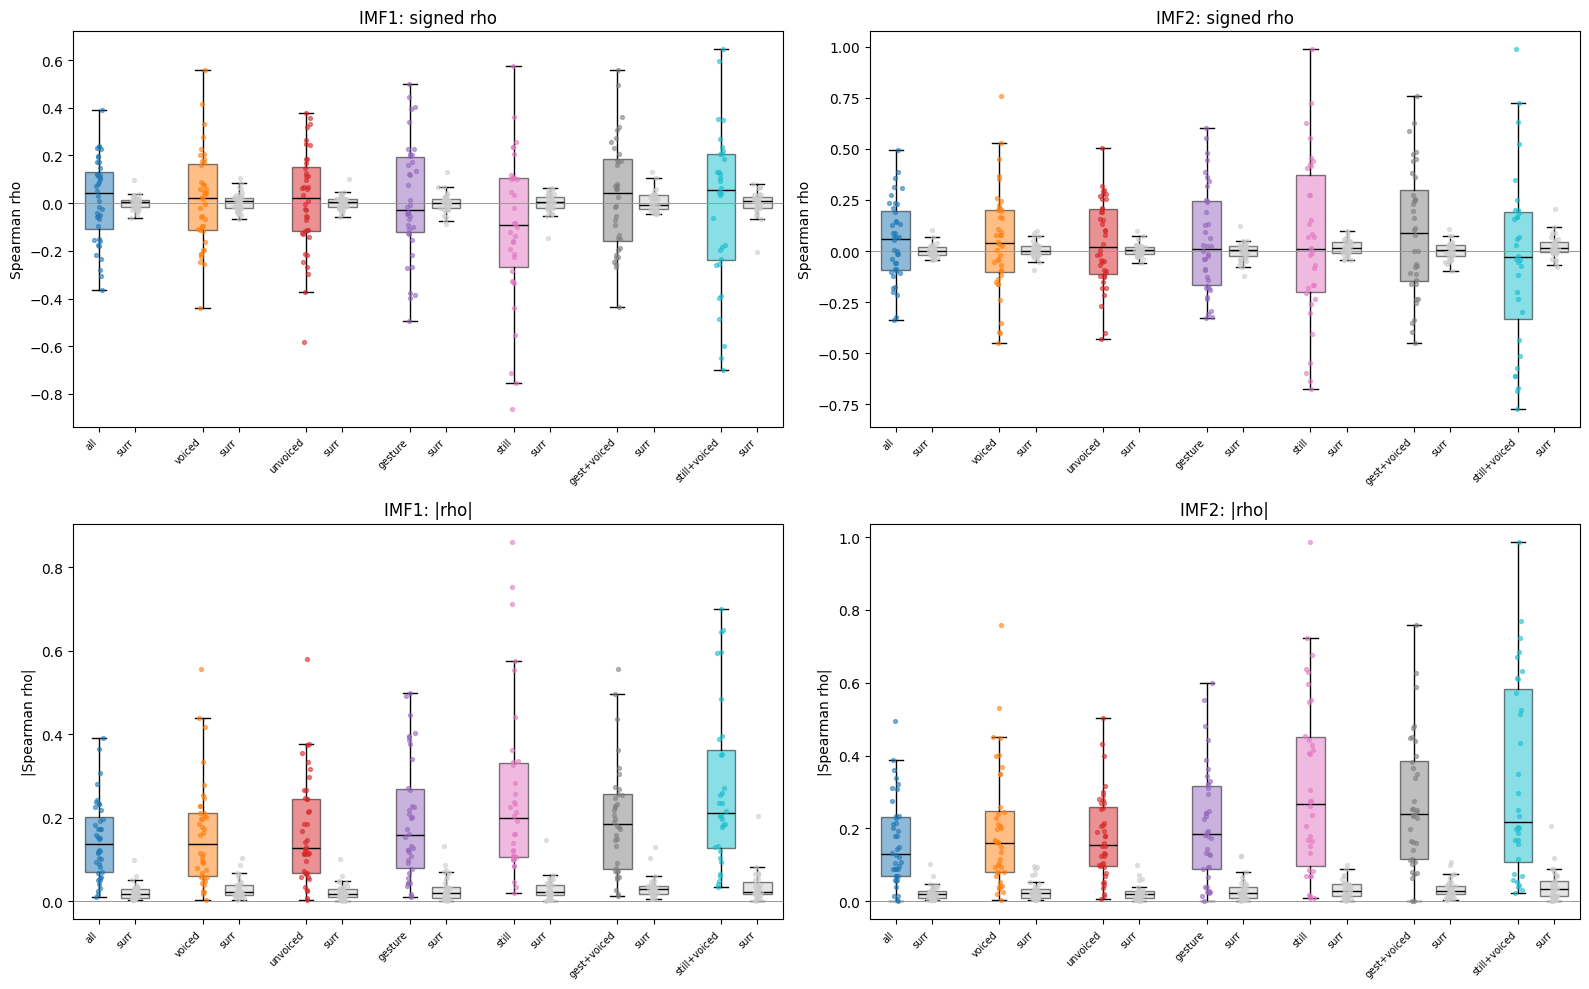

In [50]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

masks = [('', 'all'), ('_voiced', 'voiced'), ('_unvoiced', 'unvoiced'),
         ('_gest', 'gesture'), ('_still', 'still'),
         ('_gestvoiced', 'gest+voiced'), ('_stillvoiced', 'still+voiced')]
mask_colors = plt.cm.tab10(np.linspace(0, 0.9, len(masks)))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, imf in enumerate([1, 2]):
    for row, absolute in enumerate([False, True]):
        ax = axes[row, col]
        groups, labels, facecolors, positions, pos = [], [], [], [], 0
        for (suf, name), colour in zip(masks, mask_colors):
            obs = results[f'rho{suf}_imf{imf}'].to_numpy()
            sur = results[f'surr{suf}_imf{imf}'].to_numpy()
            if absolute:
                obs, sur = np.abs(obs), np.abs(sur)
            groups += [obs[np.isfinite(obs)], sur[np.isfinite(sur)]]
            positions += [pos, pos + 0.7]
            labels += [name, 'surr']
            facecolors += [colour, '0.8']
            pos += 2.0

        bp = ax.boxplot(groups, positions=positions, widths=0.55, showfliers=False,
                        patch_artist=True, medianprops=dict(color='k'))
        for patch, fc in zip(bp['boxes'], facecolors):
            patch.set_facecolor(fc); patch.set_alpha(0.5)
        for i, (vals, fc) in enumerate(zip(groups, facecolors)):
            ax.scatter(rng.normal(positions[i], 0.04, len(vals)), vals, s=8, color=fc, alpha=0.55, zorder=3)

        ax.axhline(0, color='0.6', lw=0.7)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
        ax.set_title(f"IMF{imf}: {'|rho|' if absolute else 'signed rho'}")
        ax.set_ylabel('|Spearman rho|' if absolute else 'Spearman rho')

plt.tight_layout()

In [51]:
import pandas as pd, numpy as np
from scipy.stats import spearmanr

MAINMOD = 'gestvoiced' # stillvoiced vs gestvoiced

kin = ['duration','hold_time','hand_submovements',
       'hand_mean_submovement_amplitude','hand_peak_speed','hand_mean_speed',
       'hand_peak_acceleration','hand_peak_jerk','elbow_peak_speed',
       'elbow_mean_speed','elbow_peak_jerk','space_use']
# normalize some kinematics by duration to get rates/proportions
gest['submov_rate'] = gest['hand_submovements'] / gest['duration']
gest['hold_prop']   = gest['hold_time'] / gest['duration']
per_trial = gest.groupby(['pair','trial'])[kin].median().reset_index()   # mean kinematic for all gestures per trial
per_trial['n_gestures'] = gest.groupby(['pair','trial']).size().values
per_trial['n_gestureduration'] = gest.groupby(['pair','trial'])['duration'].sum().values
merged = results.merge(per_trial, on=['pair','trial'], how='inner')

# coupling STRENGTH on voiced frames (matches the masked analysis)
merged['absrho_gestvoiced_imf1'] = merged['rho_gestvoiced_imf1'].abs()
merged['absrho_gestvoiced_imf2'] = merged['rho_gestvoiced_imf2'].abs()

rows = []
for cond, sub in merged.groupby('condition'):
    for f in kin + ['n_gestures', 'n_gestureduration']:
        for target in [f'rho_{MAINMOD}_imf1',f'rho_{MAINMOD}_imf2']:
            d = sub[[f, target]].dropna()
            if len(d) > 5:
                r, p = spearmanr(d[f], d[target])
                rows.append((cond, f, target, r, p, len(d)))
scan = pd.DataFrame(rows, columns=['condition','feature','target','r','p','n']).sort_values('p')
print(scan.head(20).to_string(index=False))

condition                         feature              target         r        p  n
    board                       space_use rho_gestvoiced_imf2 -0.309709 0.066039 36
    board                elbow_mean_speed rho_gestvoiced_imf2 -0.260746 0.124545 36
    board                 hand_mean_speed rho_gestvoiced_imf2 -0.184041 0.282604 36
    board                  hand_peak_jerk rho_gestvoiced_imf2 -0.176062 0.304354 36
    board          hand_peak_acceleration rho_gestvoiced_imf2 -0.165508 0.334706 36
    board hand_mean_submovement_amplitude rho_gestvoiced_imf2 -0.165251 0.335469 36
    board                 hand_peak_speed rho_gestvoiced_imf2 -0.161133 0.347818 36
    board                 elbow_peak_jerk rho_gestvoiced_imf2 -0.156757 0.361238 36
    board               hand_submovements rho_gestvoiced_imf2 -0.144084 0.401815 36
    board                elbow_peak_speed rho_gestvoiced_imf2 -0.132561 0.440880 36
    board                        duration rho_gestvoiced_imf2 -0.120721 0.48

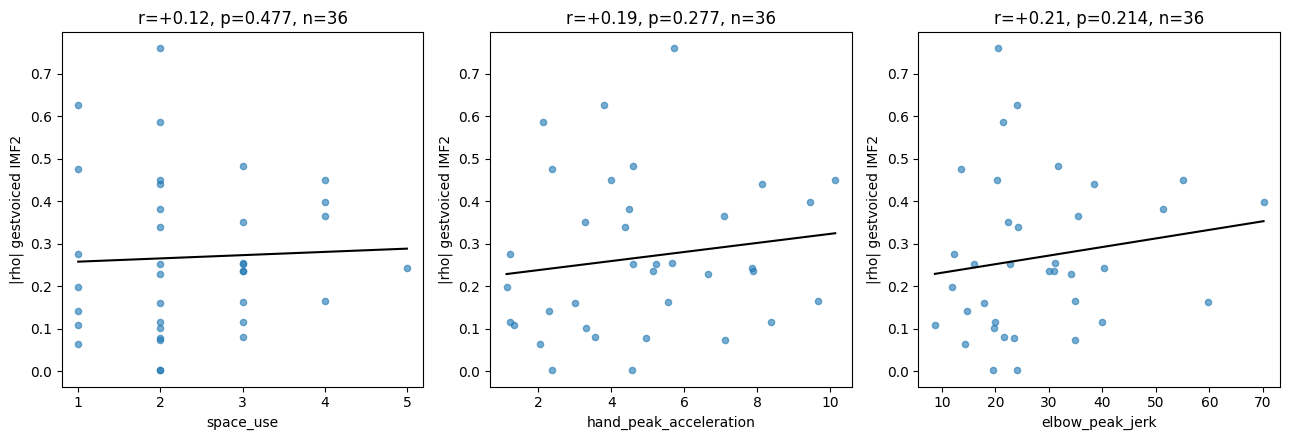

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

merged = results.merge(per_trial, on=['pair', 'trial'], how='inner')
merged[f'abs_{MAINMOD}_imf2'] = merged[f'rho_{MAINMOD}_imf2'].abs()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, feat in zip(axes, ['space_use', 'hand_peak_acceleration', 'elbow_peak_jerk']):
    d = merged[[feat, f'abs_{MAINMOD}_imf2']].dropna()
    x, y = d[feat].to_numpy(), d[f'abs_{MAINMOD}_imf2'].to_numpy()
    r, p = spearmanr(x, y)
    ax.scatter(x, y, s=20, alpha=0.6, color='C0')
    b, a = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, a + b * xs, 'k-', lw=1.5)
    ax.set_xlabel(feat); ax.set_ylabel(f'|rho| {MAINMOD} IMF2')
    ax.set_title(f'r={r:+.2f}, p={p:.3f}, n={len(d)}')
plt.tight_layout()